In [254]:
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [255]:
%reload_ext autoreload

In [256]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from time import time_ns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
print(f"Currently using {DEVICE}")

Currently using cuda


In [257]:
torch.manual_seed(0)

In [258]:
%autoreload

In [259]:
from src.data_import import *
train_loader, test_loader = load_olivetti(batch_size=BATCH_SIZE, shuffle=True)

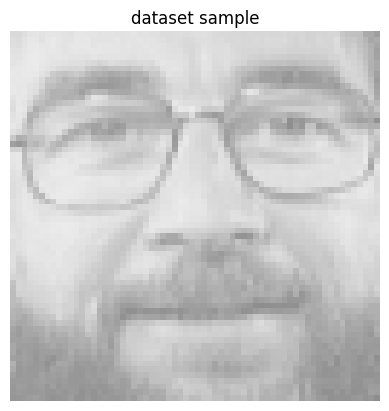

label: 27
shape: torch.Size([8, 1, 64, 64])


In [260]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample", cmap="gray")
#print label
print("label:", _[0].item())
print("shape:", x_real.shape)

In [261]:
n_heads = 3
IMAGE_SHAPE = (1, 64, 64)

In [262]:
from src.model import EBM, SmallEBM

model = EBM(image_shape=IMAGE_SHAPE, n_heads=n_heads, batch_size=BATCH_SIZE)
for head in model.heads:
    head.to(DEVICE)

model.to(DEVICE)

EBM(
  (heads): ModuleList(
    (0-2): 3 x EnergyHead(
      (conv): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
      )
      (fc): Sequential(
        (0): Linear(in_features=16384, out_features=49, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=49, out_features=1, bias=True)
      )
    )
  )
)

In [263]:
from src.sampler import ReplaySampler

sampler = ReplaySampler(model, img_shape=IMAGE_SHAPE, buffer_size=600, noise_fraction=0.05, device=DEVICE)

In [264]:
from src.information import TotalCorrelationEstimator
from src.MINE import MINE_TC_Estimator

total_correlation_estimator = MINE_TC_Estimator(n_heads, hidden_dim=32, lr=1e-3)
total_correlation_estimator.to(DEVICE)

In [265]:
# params = torch.load("./models/EBM_15_epochs_3_heads_(1, 64, 64)_shape_1782992338748688162t_OLIVETTI.pth")
# model = EBM(image_shape=(1, 64, 64), n_heads=3)
# model.load_state_dict(params)
# model.to(DEVICE)

In [266]:
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

In [267]:
epochs = 500
steps_per_epoch = len(train_loader)
warmup_steps = 800
total_steps = (epochs * steps_per_epoch) - warmup_steps
print(f"Steps={total_steps} -> Warmup={warmup_steps} + Rest={total_steps}")

Steps=16700 -> Warmup=800 + Rest=16700


In [268]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, betas=(0.000, 0.999))

# Warmup
warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps)

# Decay
decay = CosineAnnealingLR(optimizer, T_max=total_steps - warmup_steps)
scheduler = SequentialLR(optimizer, schedulers=[warmup, decay], milestones=[warmup_steps])

In [269]:
from src.train import train_one_epoch_TC, train_one_epoch, train_one_epoch_MINE
#torch.autograd.set_detect_anomaly(True, check_nan=False)

for epoch in range(epochs):
    epoch_loss, _ = train_one_epoch_MINE(
        # The essentials
        model, 
        sampler, 
        train_loader, 
        optimizer,

        # Sampler parameters
        sample_steps=30,
        sample_step_size=10.0,
        sample_noise_std=0.005,
        energy_reg=1e-1,
        tc_regularizations=0.2,
        
        # Stability
        scheduler=scheduler,
        clip_gradient=True,

        # TC regularization
        tc_estimator=total_correlation_estimator,
        
        # Device
        device=DEVICE,
        verbose=False
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")


100%|██████████| 35/35 [00:06<00:00,  5.10it/s]


Epoch 1, Loss: 0.3539


100%|██████████| 35/35 [00:06<00:00,  5.17it/s]


Epoch 2, Loss: -0.3078


100%|██████████| 35/35 [00:06<00:00,  5.20it/s]


...

Epoch 498, Loss: 0.0046


100%|██████████| 35/35 [00:06<00:00,  5.11it/s]


Epoch 499, Loss: 0.0028


100%|██████████| 35/35 [00:06<00:00,  5.11it/s]


Epoch 500, Loss: 0.0015


In [270]:
torch.save(model.state_dict(), f"./models/{model.__class__}_{epoch}_epochs_{len(model.heads)}_heads_{IMAGE_SHAPE}_shape_{time_ns()}t_OLIVETTI_Weight_Decay.pth")

EBM DIAGNOSTICS

[1] Energy on real data
  Train  →  mean=0.0082,  std=0.0222
  Test   →  mean=0.0104,  std=0.0215
  |E_test - E_train| = 0.0022  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=-0.0044,  std=0.0106
  Gap (E_real_train - E_fake) = 0.0126  (WARNING: gap inverted)

[3] Energy on pure noise
  Noise  →  mean=9.2660,  std=0.1456
  Gap (E_real_train - E_noise) = -9.2579  (ok)

[4] Per-head energy (on train batch)
  Head 0  →  mean=-0.3630,  std=0.0025
  Head 1  →  mean=0.2354,  std=0.0119
  Head 2  →  mean=0.1314,  std=0.0035
  Max off-diagonal correlation: 0.6641  (WARNING: heads are correlated)

[5] Replay buffer
  Buffer size: 600 / 600
  Buffer samples  →  mean=0.5801,  std=0.1729,  min=-0.8262,  max=1.0000

[6] Visual samples (Langevin from noise)


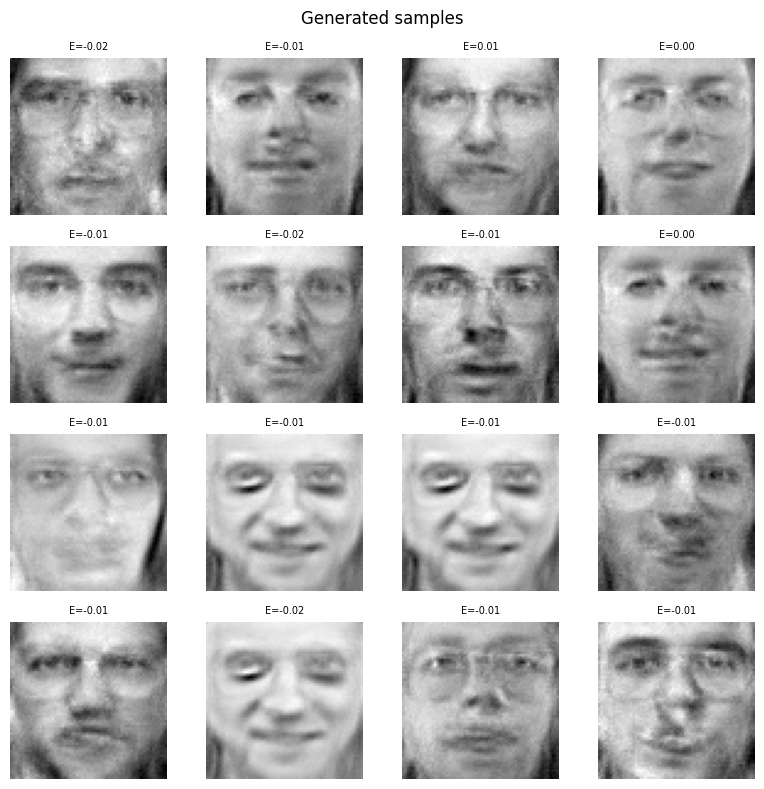


DONE


In [271]:
from src.diagnostic import diagnose

diagnose(model, sampler, IMAGE_SHAPE, train_loader, test_loader, device=DEVICE, n_samples=16)

In [272]:
model.to(DEVICE)

EBM(
  (heads): ModuleList(
    (0-2): 3 x EnergyHead(
      (conv): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
      )
      (fc): Sequential(
        (0): Linear(in_features=16384, out_features=49, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=49, out_features=1, bias=True)
      )
    )
  )
)

In [273]:
model.to(DEVICE)
samples = sampler.generate(10, steps=200, step_size=1.0, noise_std=0.005)

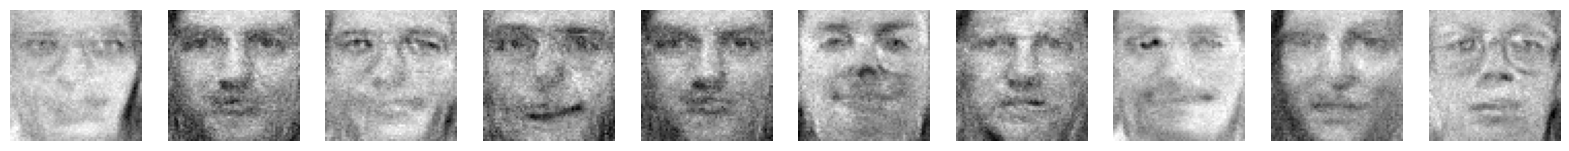

In [274]:
show_grid(samples, 10, cmap="gray")

In [275]:
# from src.plot import visualize_heads

# model.to("cpu")

# fig = visualize_heads(
#     model, 
#     steps=200, 
#     step_size=10.0, 
#     noise_std=0.01,
#     k=3,
#     cmap="Grays",
# )

# model.to(DEVICE)

In [276]:
# model = EBM(image_shape=(1,64,64), n_heads=3)
# mn = "EBM_20_epochs_(1, 64, 64)_shape_3_heads_1782902908565130435"
# f = "./models/olivetti/" + mn + ".pth"
# model.load_state_dict(torch.load(f))

In [277]:
from src.plot import visualize_head_gradients, visualize_head_abs_gradients

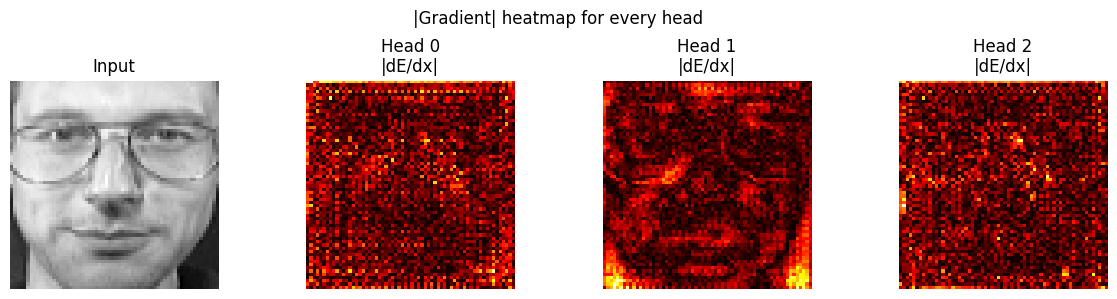

In [278]:
it = iter(test_loader)

for _ in range(0):
    it.__next__()
x0 = it.__next__()[0]

visualize_head_abs_gradients(model.to(DEVICE), x0, DEVICE)


In [279]:
from src.gradient_inspect import synthetize_image_from_head, synthetize_image

model.to("cpu")
class Combined(nn.Module):
    def __init__(self, m1, m2=None):
        super().__init__()
        self.m1 = m1
        self.m2 = m2
    def forward(self, x):
        if self.m2 is None:
            return self.m1(x)
        return self.m1(x) + self.m2(x)

img0, _ = synthetize_image_from_head(Combined(model.heads[0]), n_images=1, img_dimension=IMAGE_SHAPE[-1], steps=1_000)
img1, _ = synthetize_image_from_head(Combined(model.heads[1]), n_images=1, img_dimension=IMAGE_SHAPE[-1], steps=1_000)
img2, _ = synthetize_image_from_head(Combined(model.heads[2]), n_images=1, img_dimension=IMAGE_SHAPE[-1], steps=1_000)
img01, _ = synthetize_image_from_head(Combined(model.heads[0], model.heads[1]), n_images=1, img_dimension=IMAGE_SHAPE[-1], steps=1_000)
img02, _ = synthetize_image_from_head(Combined(model.heads[0], model.heads[2]), n_images=1, img_dimension=IMAGE_SHAPE[-1], steps=1_000)
img12, _ = synthetize_image_from_head(Combined(model.heads[1], model.heads[2]), n_images=1, img_dimension=IMAGE_SHAPE[-1], steps=1_000)

model.to(DEVICE)

EBM(
  (heads): ModuleList(
    (0-2): 3 x EnergyHead(
      (conv): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
      )
      (fc): Sequential(
        (0): Linear(in_features=16384, out_features=49, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=49, out_features=1, bias=True)
      )
    )
  )
)

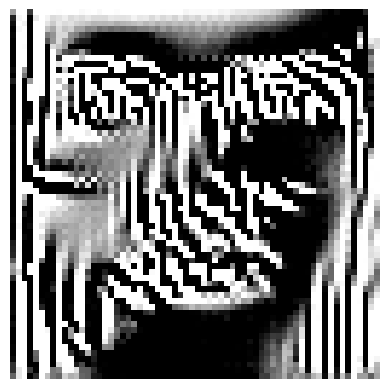

In [280]:
show_single_sample(img0, cmap="gray")

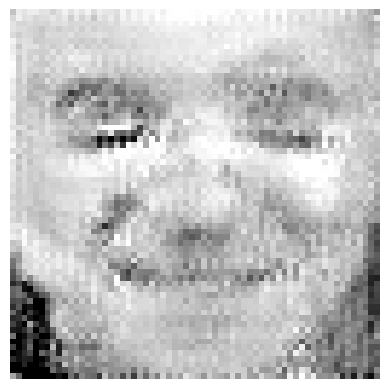

In [281]:
show_single_sample(img1, cmap="gray")

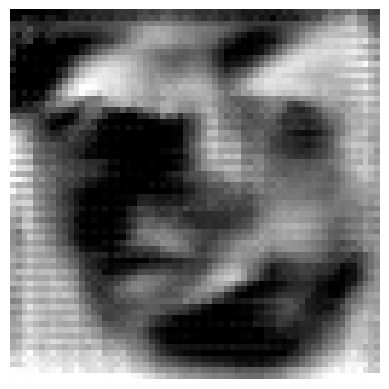

In [282]:
show_single_sample(img2, cmap="gray")

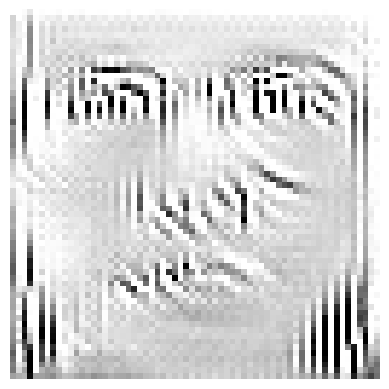

In [283]:
show_single_sample(img01, cmap="gray")

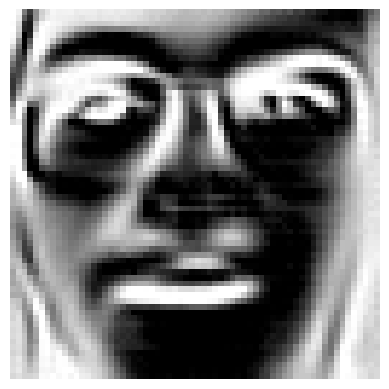

In [284]:
show_single_sample(img02, cmap="gray")

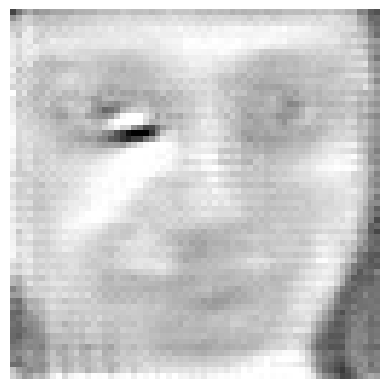

In [285]:
show_single_sample(img12, cmap="gray")

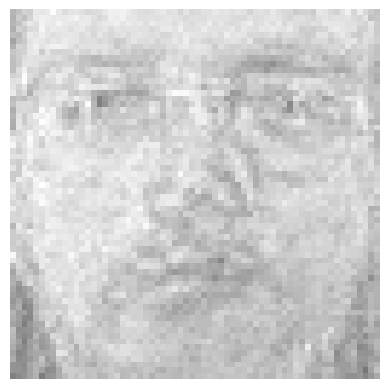

In [286]:
img, _ = synthetize_image(model.to("cpu"), img_dimension=IMAGE_SHAPE[-1], steps=5_000, step_size=1.0)
show_single_sample(img, cmap="gray")